In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

# Load data - adjusted to look in the root folder if it's not in /data
try:
    df = pd.read_csv("data/nigeria.csv")
except FileNotFoundError:
    df = pd.read_csv("nigeria.csv")

# Basic setup
df["Country"] = "Nigeria"
df.replace(-999, np.nan, inplace=True)
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [2]:
# Handle Missing Values & Outliers
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
df[cols] = df[cols].ffill() 

# Export Clean Data
df.to_csv("data/nigeria_clean.csv", index=False)
print("✅ Cleaning Complete and File Exported!")

✅ Cleaning Complete and File Exported!


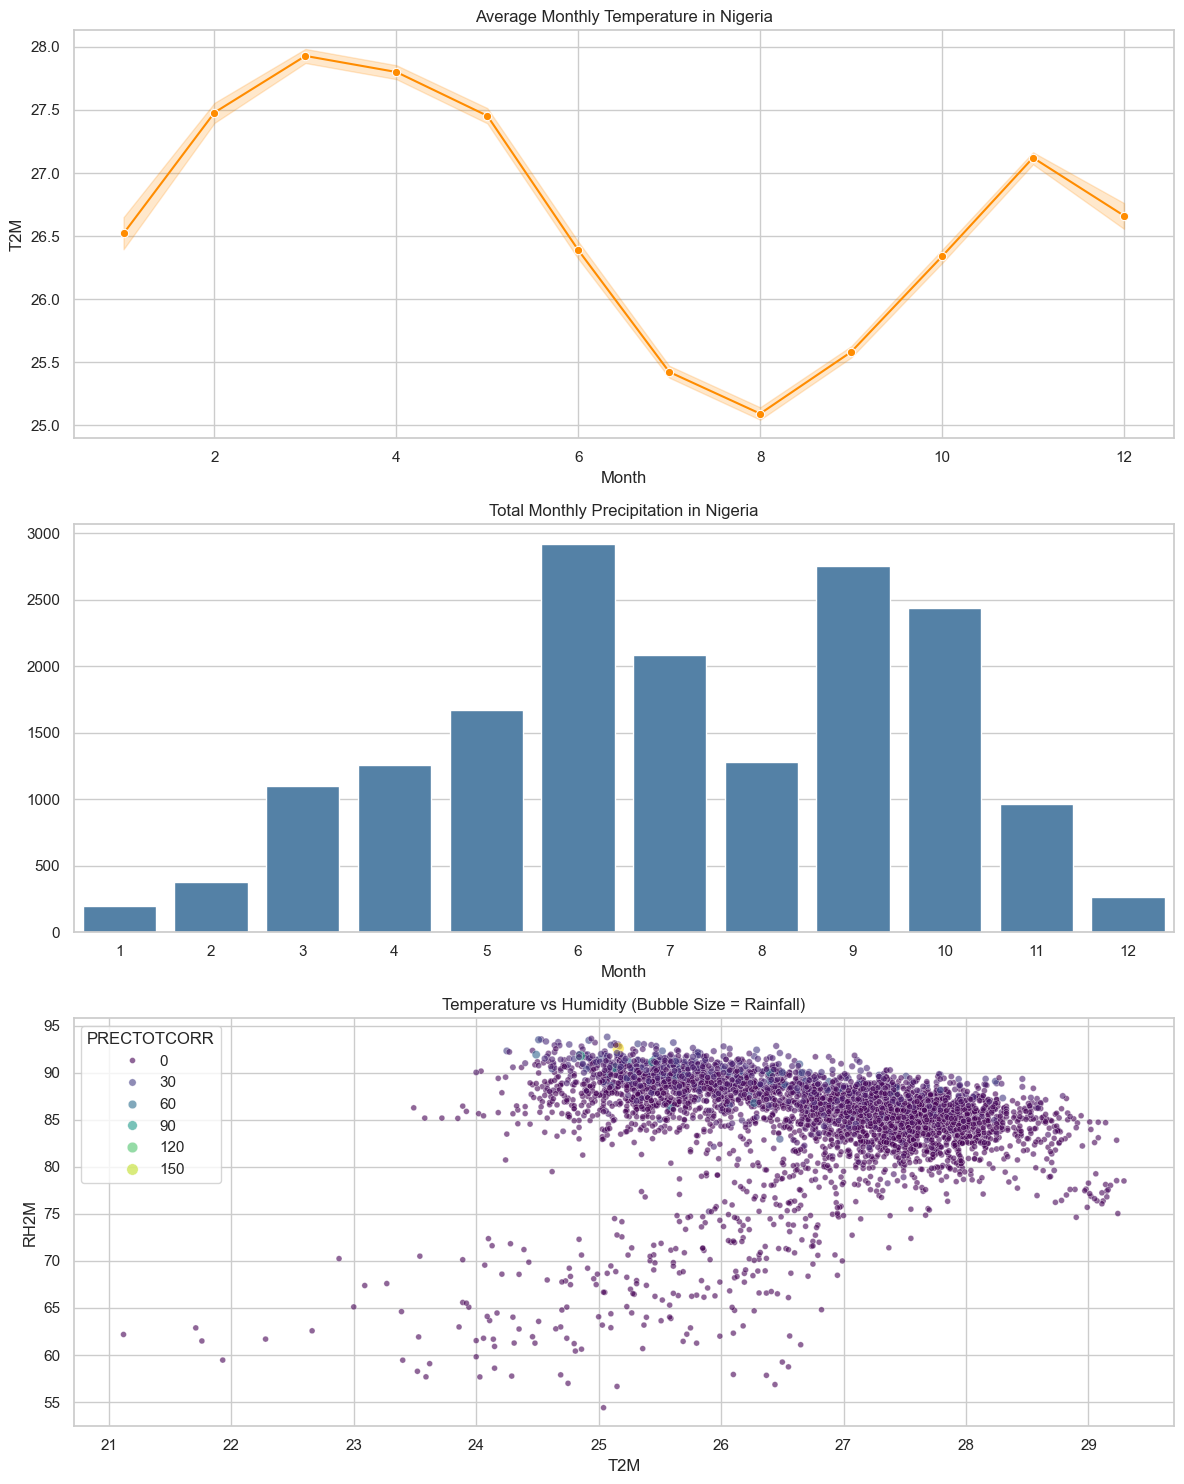

In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 15))

# 1. Temperature Line Chart
plt.subplot(3, 1, 1)
sns.lineplot(data=df, x='Month', y='T2M', marker='o', color='darkorange')
plt.title('Average Monthly Temperature in Nigeria')

# 2. Precipitation Bar Chart
plt.subplot(3, 1, 2)
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()
sns.barplot(x=monthly_rain.index, y=monthly_rain.values, color='steelblue')
plt.title('Total Monthly Precipitation in Nigeria')

# 3. THE BUBBLE CHART (Required for Task 2)
plt.subplot(3, 1, 3)
sns.scatterplot(data=df, x="T2M", y="RH2M", size="PRECTOTCORR", hue="PRECTOTCORR", alpha=0.6, palette="viridis")
plt.title("Temperature vs Humidity (Bubble Size = Rainfall)")

plt.tight_layout()
plt.show()

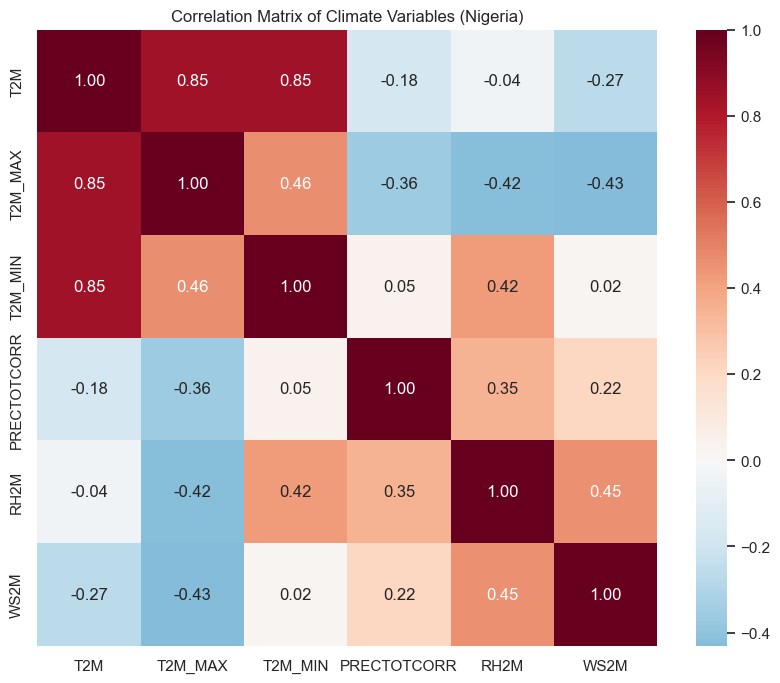

In [4]:
# Correlation & Relationship Analysis
plt.figure(figsize=(10, 8))
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr = df[weather_cols].corr()

sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation Matrix of Climate Variables (Nigeria)')
plt.show()

In [5]:
df.to_csv("data/nigeria_clean.csv", index=False)
print("Nigeria data saved!")

Nigeria data saved!
